In [3]:
from tensorflow.keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

In [2]:
len(train_data)

8982

In [3]:
len(test_data)

2246

In [4]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.5182 - loss: 2.6471 - mae: 0.0362 - mse: 0.0170 - val_accuracy: 0.6390 - val_loss: 1.7251 - val_mae: 0.0270 - val_mse: 0.0119
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6849 - loss: 1.4683 - mae: 0.0230 - mse: 0.0101 - val_accuracy: 0.7000 - val_loss: 1.3363 - val_mae: 0.0208 - val_mse: 0.0093
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7531 - loss: 1.1390 - mae: 0.0183 - mse: 0.0080 - val_accuracy: 0.7370 - val_loss: 1.1796 - val_mae: 0.0182 - val_mse: 0.0084
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7954 - loss: 0.9340 - mae: 0.0156 - mse: 0.0068 - val_accuracy: 0.7670 - val_loss: 1.0776 - val_mae: 0.0171 - val_mse: 0.0078
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8321 - loss: 0.7695 - mae: 0.0136 - mse: 0.0058 - val_accuracy: 0.7710 - val_loss: 0.9950 - val_mae: 0.0155 - val_mse: 0.0073
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms

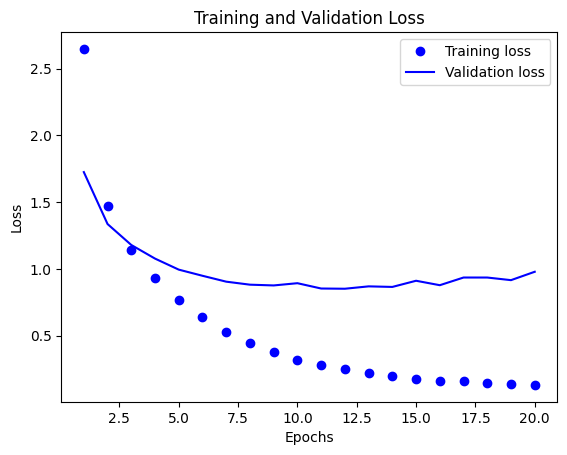

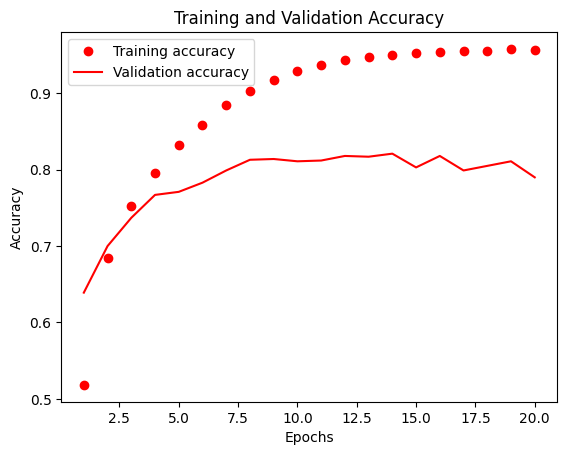

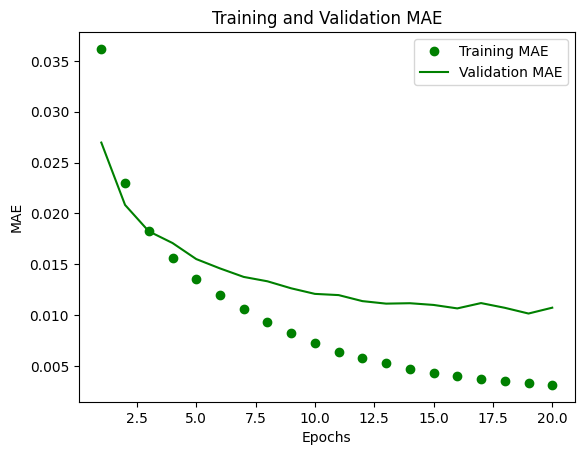

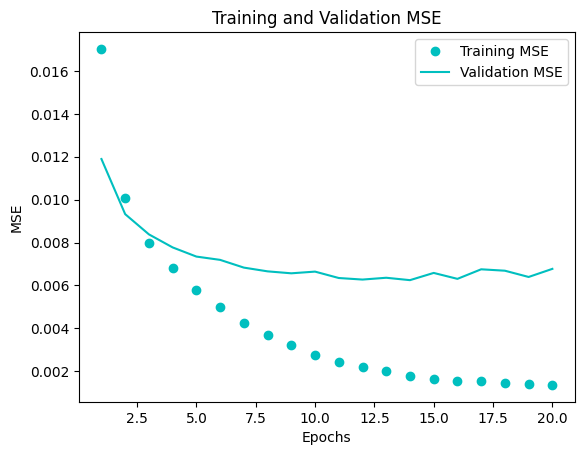

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from tensorflow.keras import layers


def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.0
    return results

# def to_one_hot(labels, dimension=46):
#     results = np.zeros((len(labels), dimension))
#     for i, label in enumerate(labels):
#         results[i, label] = 1.
#     return results
    
# y_train = to_one_hot(train_labels) 
# y_test = to_one_hot(test_labels)

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

model = keras.Sequential([
 layers.Dense(64, activation="relu"),
 layers.Dense(64, activation="relu"),
 layers.Dense(46, activation="softmax")
])

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy","mae", "mse"])
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]
history = model.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

# Lấy dữ liệu loss từ history
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')   # bo = blue dots
plt.plot(epochs, val_loss, 'b', label='Validation loss') # b = blue line
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'ro', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

mae = history.history['mae']
mse = history.history['mse']
val_mae = history.history['val_mae']
val_mse = history.history['val_mse']

# Plot MAE
plt.plot(epochs, mae, 'go', label='Training MAE')   # green dots
plt.plot(epochs, val_mae, 'g', label='Validation MAE') # green line
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# Plot MSE
plt.plot(epochs, mse, 'co', label='Training MSE')   # cyan dots
plt.plot(epochs, val_mse, 'c', label='Validation MSE') # cyan line
plt.title('Training and Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [9]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, epochs=9, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5095 - loss: 2.5983
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6855 - loss: 1.4650
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7435 - loss: 1.1438
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7980 - loss: 0.9426
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8283 - loss: 0.7866
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8544 - loss: 0.6626
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8810 - loss: 0.5538
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9002 - loss: 0.4685
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9136 - loss: 0.4010
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7916 - loss: 0.9181


In [11]:
results

[0.918121337890625, 0.7916295528411865]

In [8]:
import tensorflow as tf

# Convert data to tensors
x_train_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)
x_test_tf = tf.convert_to_tensor(x_test, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

# Initialize weights and biases
initializer = tf.initializers.GlorotUniform()

W1 = tf.Variable(initializer([10000, 64]))
b1 = tf.Variable(tf.zeros([64]))
W2 = tf.Variable(initializer([64, 64]))
b2 = tf.Variable(tf.zeros([64]))
W3 = tf.Variable(initializer([64, 46]))
b3 = tf.Variable(tf.zeros([46]))

# Forward pass
def model_forward(x):
    z1 = tf.matmul(x, W1) + b1
    a1 = tf.nn.relu(z1)
    z2 = tf.matmul(a1, W2) + b2
    a2 = tf.nn.relu(z2)
    z3 = tf.matmul(a2, W3) + b3
    y_pred = tf.nn.softmax(z3)
    return y_pred

# Loss function
def loss_fn(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_true, y_pred))

# Optimizer
optimizer = tf.optimizers.RMSprop(learning_rate=0.001)

# Training step
def train_step(x, y):
    with tf.GradientTape() as tape:
        y_pred = model_forward(x)
        loss = loss_fn(y, y_pred)
    gradients = tape.gradient(loss, [W1, b1, W2, b2, W3, b3])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2, W3, b3]))
    return loss

# Training loop
epochs = 9
batch_size = 512
num_batches = len(x_train) // batch_size

for epoch in range(epochs):
    for i in range(num_batches):
        start = i * batch_size
        end = start + batch_size
        x_batch = x_train_tf[start:end]
        y_batch = y_train_tf[start:end]
        loss = train_step(x_batch, y_batch)
    print(f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}")

# Evaluation
y_pred_test = model_forward(x_test_tf)
accuracy = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(y_pred_test, 1), tf.argmax(y_test_tf, 1)), tf.float32))
print("Test accuracy:", accuracy.numpy())


Epoch 1, Loss: 1.9500
Epoch 2, Loss: 1.4285
Epoch 3, Loss: 1.1624
Epoch 4, Loss: 0.9848
Epoch 5, Loss: 0.8453
Epoch 6, Loss: 0.7262
Epoch 7, Loss: 0.6239
Epoch 8, Loss: 0.5379
Epoch 9, Loss: 0.4759
Test accuracy: 0.7907391


In [16]:
predictions = model.predict(x_test)
print(predictions[0].shape)
print(np.sum(predictions[0]))
print(np.argmax(predictions[0]))

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
(46,)
1.0000001
3


In [18]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, epochs=9, batch_size=512)
results = model.evaluate(x_test, y_test)
print(results)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5060 - loss: 2.7254
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6682 - loss: 1.5324
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7426 - loss: 1.1644
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7986 - loss: 0.9387
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8344 - loss: 0.7665
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8667 - loss: 0.6268
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8877 - loss: 0.5222
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9077 - loss: 0.4356
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9227 - loss: 0.3670
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7921 - loss: 0.9240
[0.9240216016769409, 0.7920747995376587]


In [23]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(46, activation="softmax")
])
model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(partial_x_train, partial_y_train, epochs=20, batch_size=128, validation_data=(x_val, y_val))
results = model.evaluate(x_test, y_test)
print(results)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.3504 - loss: 2.7728 - val_accuracy: 0.3600 - val_loss: 2.2979
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3933 - loss: 2.0372 - val_accuracy: 0.4220 - val_loss: 1.8697
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4877 - loss: 1.5577 - val_accuracy: 0.6270 - val_loss: 1.4882
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6936 - loss: 1.2272 - val_accuracy: 0.6880 - val_loss: 1.3367
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7383 - loss: 1.0736 - val_accuracy: 0.6930 - val_loss: 1.2897
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7511 - loss: 0.9709 - val_accuracy: 0.6970 - val_loss: 1.2602
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7660 - loss: 0.8897 - val_accuracy: 0.7060 - val_loss: 1.2595
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7880 - loss: 0.8217 - val_accuracy: 0.7160 - v

In [31]:
#2 lop
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    #layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"], )
model.fit(partial_x_train, partial_y_train, epochs=9, batch_size=512, validation_data=(x_val, y_val))
results = model.evaluate(x_test, y_test)
print(results)

Epoch 1/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.5157 - loss: 2.6691 - val_accuracy: 0.6290 - val_loss: 1.9318
Epoch 2/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6844 - loss: 1.6003 - val_accuracy: 0.6960 - val_loss: 1.4368
Epoch 3/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7572 - loss: 1.1957 - val_accuracy: 0.7490 - val_loss: 1.1995
Epoch 4/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8009 - loss: 0.9580 - val_accuracy: 0.7770 - val_loss: 1.0693
Epoch 5/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8361 - loss: 0.7970 - val_accuracy: 0.7950 - val_loss: 0.9867
Epoch 6/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8693 - loss: 0.6725 - val_accuracy: 0.8060 - val_loss: 0.9263
Epoch 7/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8881 - loss: 0.5759 - val_accuracy: 0.8130 - val_loss: 0.8828
Epoch 8/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9025 - loss: 0.4949 - val_accuracy: 0.8130 - val_loss:

In [32]:
#4 lop
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"], )
model.fit(partial_x_train, partial_y_train, epochs=9, batch_size=512, validation_data=(x_val, y_val))
results = model.evaluate(x_test, y_test)
print(results)

Epoch 1/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.4624 - loss: 2.9037 - val_accuracy: 0.6240 - val_loss: 1.8559
Epoch 2/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6647 - loss: 1.5909 - val_accuracy: 0.6700 - val_loss: 1.4482
Epoch 3/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.7273 - loss: 1.2384 - val_accuracy: 0.7240 - val_loss: 1.2338
Epoch 4/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7663 - loss: 1.0373 - val_accuracy: 0.7280 - val_loss: 1.1618
Epoch 5/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8011 - loss: 0.8787 - val_accuracy: 0.7660 - val_loss: 1.0973
Epoch 6/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8289 - loss: 0.7428 - val_accuracy: 0.7660 - val_loss: 1.0661
Epoch 7/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8583 - loss: 0.6209 - val_accuracy: 0.7770 - val_loss: 1.0405
Epoch 8/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8770 - loss: 0.5354 - val_accuracy: 0.7900 - val_loss:

In [35]:
#32 unit
model = keras.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"], )
model.fit(partial_x_train, partial_y_train, epochs=9, batch_size=512, validation_data=(x_val, y_val))
results = model.evaluate(x_test, y_test)
print(results)

Epoch 1/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.3440 - loss: 3.4081 - val_accuracy: 0.4960 - val_loss: 2.8251
Epoch 2/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5910 - loss: 2.3574 - val_accuracy: 0.6500 - val_loss: 1.9510
Epoch 3/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6837 - loss: 1.6957 - val_accuracy: 0.6840 - val_loss: 1.5449
Epoch 4/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7197 - loss: 1.3546 - val_accuracy: 0.7010 - val_loss: 1.3454
Epoch 5/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7534 - loss: 1.1474 - val_accuracy: 0.7230 - val_loss: 1.2089
Epoch 6/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7849 - loss: 0.9979 - val_accuracy: 0.7530 - val_loss: 1.1137
Epoch 7/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8145 - loss: 0.8791 - val_accuracy: 0.7630 - val_loss: 1.0567
Epoch 8/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8311 - loss: 0.7780 - val_accuracy: 0.7710 - val_loss:

In [36]:
#128 unit
model = keras.Sequential([
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"], )
model.fit(partial_x_train, partial_y_train, epochs=9, batch_size=512, validation_data=(x_val, y_val))
results = model.evaluate(x_test, y_test)
print(results)

Epoch 1/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.5462 - loss: 2.3270 - val_accuracy: 0.6580 - val_loss: 1.4890
Epoch 2/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.7230 - loss: 1.2828 - val_accuracy: 0.7360 - val_loss: 1.1976
Epoch 3/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7845 - loss: 0.9812 - val_accuracy: 0.7720 - val_loss: 1.0355
Epoch 4/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.8331 - loss: 0.7666 - val_accuracy: 0.7940 - val_loss: 0.9400
Epoch 5/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.8733 - loss: 0.5889 - val_accuracy: 0.7950 - val_loss: 0.9068
Epoch 6/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8989 - loss: 0.4775 - val_accuracy: 0.8300 - val_loss: 0.8324
Epoch 7/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9184 - loss: 0.3701 - val_accuracy: 0.8300 - val_loss: 0.8065
Epoch 8/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9263 - loss: 0.3199 - val_accuracy: 0.8050 - val_loss